In [7]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "elo-meriem"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "elo-meriem" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Fractional Factorial Design"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/elo-meriem/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Fractional Factorial Design/STAT-7220-Applied-Experimental-Design
⚠️ WARNING: You are working in the instructor's repo, not your fork!
💡 Please fork the repo to your own account and update `github_username` above.
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Fractional Factorial Design/STAT-7220-Applied-Experimental-Design/Fractional Factorial Design


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: April 13, 2026

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

determine which combination of sole material, insole thickness and fabric breathability maximizes the comfort of a new running shoe as rated by NCAA Division I cross-country athletes after a 30-minute treadmill run.


2.  Specify the outcome variable and how it is measured.

The comfort level of the shoe measured by the athletes rating after the 30 minutes treadmill run

3.  Specify the independent variables. What lurking variables may be present?

Independent variables: the three factors:
 - Sole Material (A): EVA foam ,gel-infused foam
 - Insole Thickness (B):  3mm,  6mm
 - Fabric Breathability (C):woven fabric, mesh fabric |


lurking variables:
- Foot shape
- Fatigue level before the run
- Environmental conditions (Temp and humidity )


4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

A full factorial design investigates every possible combination of factor levels. If an experiment has k factors, and each factor has n levels, the total number of  runs is $n^k$

A $2^k$ factorial design is a specific type of full factorial design where there are k factors, each tested at only two level.

The latter is the preffered in this case because we have 3 factors: Sole Material (A),Insole Thickness (B),and Fabric Breathability (C) tested at Two levels.


5.  State the sets of null and alternative hypotheses for this experiment.

##### Main factors
$$ H_{01}: \alpha_{\text{EVA}} = \alpha_{\text{GEL}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

$$ H_{02}: \beta_{\text{3mm}} = \beta_{\text{6mm}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

$$ H_{03}: \gamma_{\text{mesh}} = \gamma_{\text{woven}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$


##### Two-Factor Interactions

$$H_{04}: (\alpha\beta)_{ij} = 0 \quad \text{for all } i,j$$
$$H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0$$

$$H_{05}: (\alpha\gamma)_{ik} = 0 \quad \text{for all } i,k$$
$$H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0$$

$$H_{06}: (\beta\gamma)_{jk} = 0 \quad \text{for all } j,k$$
$$H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0$$

##### Three-Factor Interaction
$$H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \quad \text{for all } i,j,k$$

$$H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq0$$


6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [3]:
## Question 6 Code ##

## Import pandas library ##
import pandas as pd
import numpy as np

## Import xlsx File ##

Shoe_comfort_ds = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/Shoe Comfort Experiment.xlsx")

## Data Integrity Check ##

print(Shoe_comfort_ds.info())

#main effects:
## Means and Standard Deviations for sole_material ##
sole_material_stats = Shoe_comfort_ds.groupby("sole_material")["comfort"].agg(['mean','std'])
print(sole_material_stats)

## Means and Standard Deviations for insole_thickness ##
insole_thickness_stats = Shoe_comfort_ds.groupby("insole_thickness")["comfort"].agg(['mean','std'])
print(insole_thickness_stats)

## Means and Standard Deviations for breathability ##
breathability_stats = Shoe_comfort_ds.groupby("breathability")["comfort"].agg(['mean','std'])
print(breathability_stats)

#two-way interactions:
material_thickness_stats = Shoe_comfort_ds.groupby(['sole_material','insole_thickness'])['comfort'].agg(['mean','std'])
print(material_thickness_stats)

material_breathability_stats = Shoe_comfort_ds.groupby(['sole_material','breathability'])['comfort'].agg(['mean','std'])
print(material_breathability_stats)

thickness_breathability_stats = Shoe_comfort_ds.groupby(['insole_thickness','breathability'])['comfort'].agg(['mean','std'])
print(thickness_breathability_stats)

#three-way interactions:
Shoe_comfort_ds_stats = Shoe_comfort_ds.groupby(['sole_material','insole_thickness','breathability'])['comfort'].agg(['mean','std'])
print(Shoe_comfort_ds_stats)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   comfort           24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
                   mean       std
sole_material                    
EVA            7.093638  1.076122
Gel            9.043596  1.545309
                      mean       std
insole_thickness                    
3mm               7.441465  1.387030
6mm               8.695768  1.684642
                   mean       std
breathability                    
Mesh           7.504218  1.272221
Woven          8.633016  1.818369
                                    mean       std
sole_material insole_thickness                    
EVA           3mm               

Main factors:

- Sole Material: Gel soles has higher comfort (9.04 vs 7.09): reject H01

- Insole Thickness: 6mm insoles has higher comfort (8.70 vs 7.44): reject H02

- Fabric Breathability : Woven fabric has higher comfort (8.63 vs 7.50): reject H03

 Two way factors:

 - Gel*6mm shows higher comfort :reject H04
 - Gel*Woven shows higher comfort :reject H05
 - woven* 6mm shows higher comfort : reject H06

 three way factor:
 -gel* 6mm* woven shows higher comfort :reject H07

conclusion :the results support the alternative hypotheses

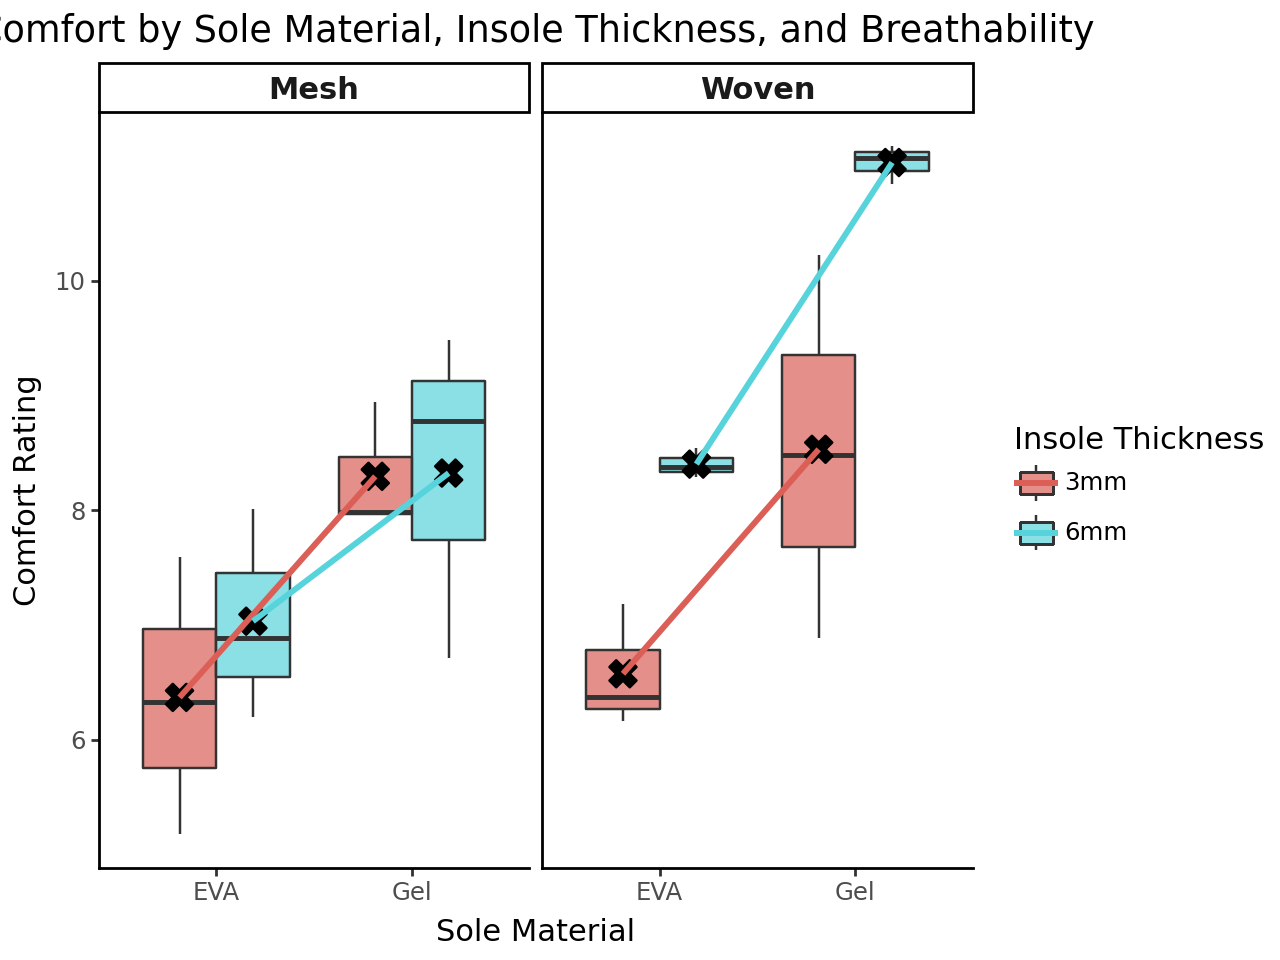

In [4]:

#visualization

# Create mean table for plotting points/lines
shoe_means = (
    Shoe_comfort_ds
    .groupby(['sole_material', 'insole_thickness', 'breathability'])['comfort']
    .mean()
    .reset_index(name='mean')
)

from plotnine import *

# Define dodge position
box_dodge = position_dodge(0.75)

p = (
    ggplot(Shoe_comfort_ds, aes(x='sole_material', y='comfort')) +

    # 1. Boxplots (distribution)
    geom_boxplot(
        aes(fill='insole_thickness'),
        alpha=0.7,
        position=box_dodge
    ) +

    # 2. Mean points
    geom_point(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black'
    ) +

    # 3. Mean lines (interaction)
    geom_line(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness', color='insole_thickness'),
        size=1.2,
        position=box_dodge
    ) +

    # 4. Facet by third factor (KEY for 3-factor design)
    facet_wrap('~breathability', ncol=2) +

    # 5. Labels and styling
    labs(
        title="Comfort by Sole Material, Insole Thickness, and Breathability",
        x="Sole Material",
        y="Comfort Rating",
        fill="Insole Thickness",
        color="Insole Thickness"
    ) +

    theme_classic() +
    theme(
        plot_title=element_text(hjust=0.5),
        strip_text=element_text(size=11, weight='bold')
    )
)

p


**Interpreting the Main Effects:**

Sole Material: There is a clear increase in comfort ratings when moving from EVA to Gel across all panels (both Mesh and Woven, and for both insole thickness levels). This indicates a strong main effect of sole material on comfort
.
Insole Thickness: Within each combination of sole material and breathability, the 6mm insole generally produces higher comfort ratings than the 3mm insole. This consistent upward shift suggests that insole thickness has a meaningful positive main effect on comfort.

Breathability: Comparing the two facets, the Woven fabric panel consistently shows higher comfort ratings than the Mesh panel across nearly all factor combinations. This suggests that breathability has a strong main effect, with Woven outperforming Mesh.


** Interpreting the Two-Way Interactions **

Sole Material*Insole Thickness: The slopes of the lines connecting 3mm to 6mm are very similar for both EVA and Gel.  
This suggests a lack of a significant two-way interaction effect between insole thickness and sole material

Sole Material*Breathability: The difference in slopes between EVA and Gel becomes more noticeable in the Woven condition than in the Mesh condition.
The interaction lines for Gel show a steeper increase in comfort under Woven fabric suggesting a moderate interaction.

Insole Thickness*Breathability: The slopes of the lines from 3mm to 6mm are shallow in the Mesh facet but much steeper in the Woven facet.
This difference in slopes indicates a strong interaction: the effect of increasing insole thickness depends heavily on breathability, with Woven amplifying the benefit of thicker insoles

**Interpreting the Three-Way Interaction**

There is mild evidence of a three-way interaction, driven mainly by how the slope of insole thickness changes across breathability conditions particularly for the Gel sole condition

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


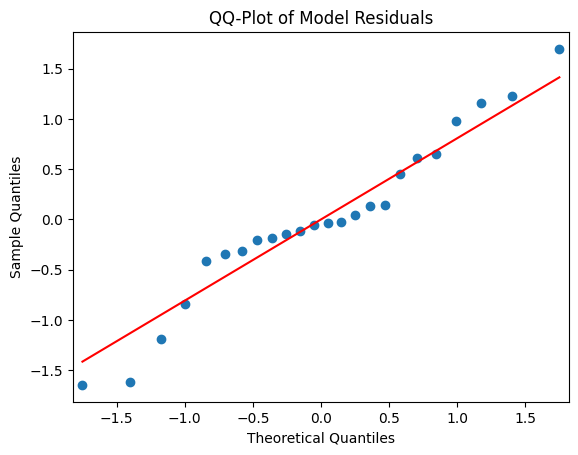

Shapiro-Wilk Test Results:
Statistic: 0.959532741725587
p-value: 0.42910705030991836
Fail to reject H0: Residuals are approximately normal.


In [4]:
## Question 7 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Fit Full Factorial Model ##
model = ols('comfort ~ sole_material*insole_thickness*breathability', data=Shoe_comfort_ds).fit()

#residuals:
residuals = model.resid

#QQ-Plot

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

#Shapiro-will test :
from scipy import stats

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")

if shapiro_test.pvalue < 0.05:
    print("Reject H0: Residuals are NOT normally distributed.")
else:
    print("Fail to reject H0: Residuals are approximately normal.")


Since most of the points in the QQ plot fall approximately along the diagonal line, and the p-value from the Shapiro–Wilk test is greater than 0.05, so we fail to reject the null hypothesis of normality.
Therefore, there is sufficient evidence to conclude that the normality assumption is satisfied


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


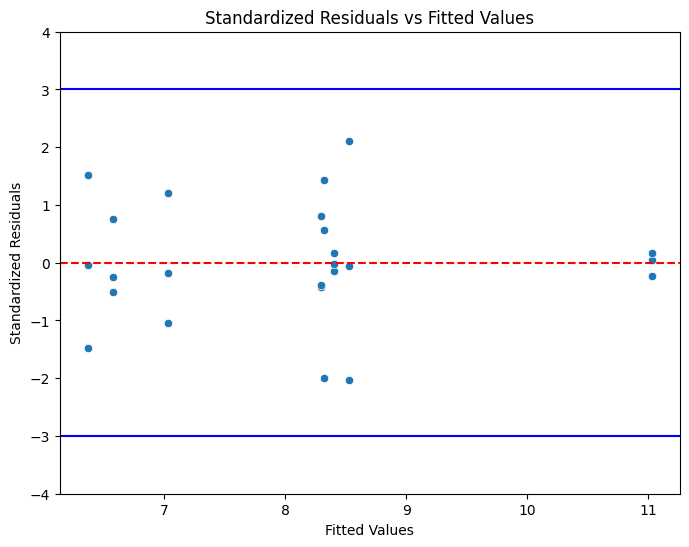

F-statistic: 2.2615166027197584
F p-value: 0.08366429231760693
Fail to reject the null hypothesis - Variances are equal.


In [5]:
## Question 8 Code ##

#Homogeneity of Variance
#Standardized Residuals vs Fitted

import seaborn as sns

standardized_residuals = model.get_influence().resid_studentized_internal
fitted_values = model.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)

plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')

plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs Fitted Values")
plt.style.use('classic')
plt.show()

## Run B-P Test ##

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")


In the standardized residuals vs. fitted values plot:
- none of our points are greater than +3 or less than -3
- the points appear randomly scattered around the horizontal line at 0
- the spread of points appears roughly constant across all fitted values.

and The B-P test p-value is greater than 0.05

we can conclude that the assumption of constant variance is satisfied


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [6]:
## Question 9 Code ##

## Print ANOVA Table Results ##

anova_table = sm.stats.anova_lm(model, typ=3)

## Add Significance Column ##

anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")

## Print Table Minus Intercept and Residual Rows ##

print(anova_table.drop(index=["Intercept", "Residual"]))

                                                sum_sq   df         F  \
sole_material                                 5.564969  1.0  5.696617   
insole_thickness                              0.661288  1.0  0.676932   
breathability                                 0.063498  1.0  0.065000   
sole_material:insole_thickness                0.303143  1.0  0.310314   
sole_material:breathability                   0.000661  1.0  0.000676   
insole_thickness:breathability                1.013879  1.0  1.037864   
sole_material:insole_thickness:breathability  0.641055  1.0  0.656220   

                                                PR(>F)     Significance  
sole_material                                 0.029691      Significant  
insole_thickness                              0.422739  Not Significant  
breathability                                 0.802009  Not Significant  
sole_material:insole_thickness                0.585197  Not Significant  
sole_material:breathability                  


**Interaction Effects:**

The three-way interaction term (Sole Material*Insole Thickness* Breathability) was *not statistically significant* (F = 0.66, p = 0.43).

The two-way interaction terms (Sole*Insole, Sole* Breathability, Insole*Breathability) were also *not statistically significant* (all p > 0.05).

This confirms the descriptive analysis of the means and suggests that interactions do not strongly influence comfort

**Main Effects:**

The main effect of Sole Material was *statistically significant*(F = 5.70, p = 0.0297), indicating that Gel soles provide higher comfort than EVA soles.

The main effect of Insole Thickness was *not statistically significant* (F = 0.68, p = 0.423), suggesting no reliable difference between 3mm and 6mm insoles.

The main effect of Breathability was *not statistically significant* (F = 0.065, p = 0.802), suggesting no reliable difference between Mesh and Woven fabrics.


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [9]:
#Question 10

## Load pingouin ##
#!pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(dv='comfort',between=["sole_material","insole_thickness","breathability"],data=Shoe_comfort_ds,effsize="np2").round(4)

print(mod_p[["Source","np2"]])


                                             Source     np2
0                                     sole_material  0.5934
1                                  insole_thickness  0.3765
2                                     breathability  0.3285
3                  sole_material * insole_thickness  0.0000
4                     sole_material * breathability  0.0429
5                  insole_thickness * breathability  0.2405
6  sole_material * insole_thickness * breathability  0.0394
7                                          Residual     NaN


- The sole_material is the most influential factor, explaining 59% of the variance in comfort.
- Insole_thickness also has a strong impact, explaining 38% of the variance in comfort
- breathability accounts for 33% of the effect.
- The two-way interaction between sole_material × insole_thickness has no effect.
- The two-way interaction insole_thickness × breathability has a medium effect, explaining 24% of the variance
 -sole_material × breathability has a very small effect (4%), similar to the three-way interaction sole_material × insole_thickness × breathability.


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

Sole Material: Gel (mean comfort = 9.04) and statistically significant (F = 5.70, p = 0.0297)

Insole Thickness: 6mm (mean comfort = 8.70), not statistically significant

Fabric Breathability: Woven(mean comfort = 8.63), not statistically significant

The combination of Gel *6mm*Woven yielded the highest observed mean comfort = 11.03 making it the most comfortable choice in practice.
Interactions are minimal, so the main effects dominate, meaning this combination is optimal without risk of negative interactions.

## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

determine which combination of GPS Accuracy (A), Battery Life (B), and Display size (C) maximizes user satisfaction for a new fitness band, as rated by NCAA Division I cross-country athletes after one month of use during their competition season

2.  Specify the outcome variable and how it is measured.

User satisfaction with the fitness band which is measured using a reported rating scale from 1 to 10

3.  Specify the independent variables. What lurking variables may be present?

independent variables:
- GPS Accuracy (A)
- Battery Life (B)
- Display size (C)

lurking variables:
- Amount of sweat produced by the user
- Type of activity
- Weather conditions (temperature, humidity)

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

full $2^k$ factorial design examines all possible combinations of K factors at two levels each. in this experiment with three factors (GPS accuracy, battery life and display), a full design would require 8runs

$2^{3-1}$ factional factorial design uses only a fraction of the full design , in this case 4 runs

5.  State the sets of null and alternative hypotheses for this experiment.

##### Main factors
$$ H_{01}: \alpha_{\text{A-}} = \alpha_{\text{A+}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

$$ H_{02}: \beta_{\text{B-}} = \beta_{\text{B+}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

$$ H_{03}: \gamma_{\text{C-}} = \gamma_{\text{C+}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$


##### Two-Factor Interactions

$$H_{04}: (\alpha\beta)_{ij} = 0 \quad \text{for all } i,j$$
$$H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0$$

$$H_{05}: (\alpha\gamma)_{ik} = 0 \quad \text{for all } i,k$$
$$H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0$$

$$H_{06}: (\beta\gamma)_{jk} = 0 \quad \text{for all } j,k$$
$$H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0$$

##### Three-Factor Interaction
$$H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \quad \text{for all } i,j,k$$

$$H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq0$$

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?


Each main effect is confounded with a two-factor interaction:

- Effect of A (GPS Accuracy) is aliased with BC (Battery*Display)
- Effect of B (Battery Life) is aliased with AC (GPS*Display)
- Effect of C (Display) is aliased with AB (GPS*Battery)


7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [22]:
## Question 7 Code ##

## Import Relevant Libraries ##
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan


## Load the Data ##

Band_Experiment_ds = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/Fitness Band Experiment.xlsx")

## Explore the Data ##
print(Band_Experiment_ds.columns)
print(Band_Experiment_ds.head())
print(Band_Experiment_ds.info())

## Reshape the Data and Calculate Summary Statistics ##
fitness_long = (
    Band_Experiment_ds
    .melt(
        id_vars=["Satisfaction"],
        value_vars=["GPS_Accuracy", "Battery_Life", "Display"],
        var_name="Effect",
        value_name="Level"
    )
    .groupby(["Effect", "Level"], as_index=False)
    .agg(
        mean=("Satisfaction", "mean"),
        sd=("Satisfaction", "std")
    )
)

## Map factor names to letters ##
effect_map = {
    "GPS_Accuracy": "A",
    "Battery_Life": "B",
    "Display": "C"
}
fitness_long["Effect_Letter"] = fitness_long["Effect"].map(effect_map)

## Order by factor letters ##
fitness_long = fitness_long.sort_values("Effect_Letter").reset_index(drop=True)

print(fitness_long)



Index(['Run_ID', 'Replicate', 'GPS_Accuracy', 'Battery_Life', 'Display',
       'Satisfaction'],
      dtype='object')
   Run_ID  Replicate GPS_Accuracy Battery_Life Display  Satisfaction
0       1          1     Standard      6 Hours   Large          5.97
1       1          2     Standard      6 Hours   Large          5.92
2       1          3     Standard      6 Hours   Large          5.26
3       2          1         High      6 Hours   Small          4.76
4       2          2         High      6 Hours   Small          5.21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Run_ID        12 non-null     int64  
 1   Replicate     12 non-null     int64  
 2   GPS_Accuracy  12 non-null     object 
 3   Battery_Life  12 non-null     object 
 4   Display       12 non-null     object 
 5   Satisfaction  12 non-null     float64
dtypes: float64(1), i

Main factors:

GPS Accuracy: High accuracy shows higher satisfaction (6.93 vs 4.88): reject H01
Battery Life: 12 hours shows higher satisfaction (6.34 vs 5.47): reject H02
Display Size: Large display shows higher satisfaction (7.18 vs 4.63): reject H03

Two-way factors :

High GPS*12-hour battery shows higher satisfaction: reject H04
High GPS*Large display shows higher satisfaction: reject H05
12-hour battery*Large display shows higher satisfaction: reject H06

Three-way factors:

High GPS*12-hour battery*Large display shows highest satisfaction overall: reject H07


8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


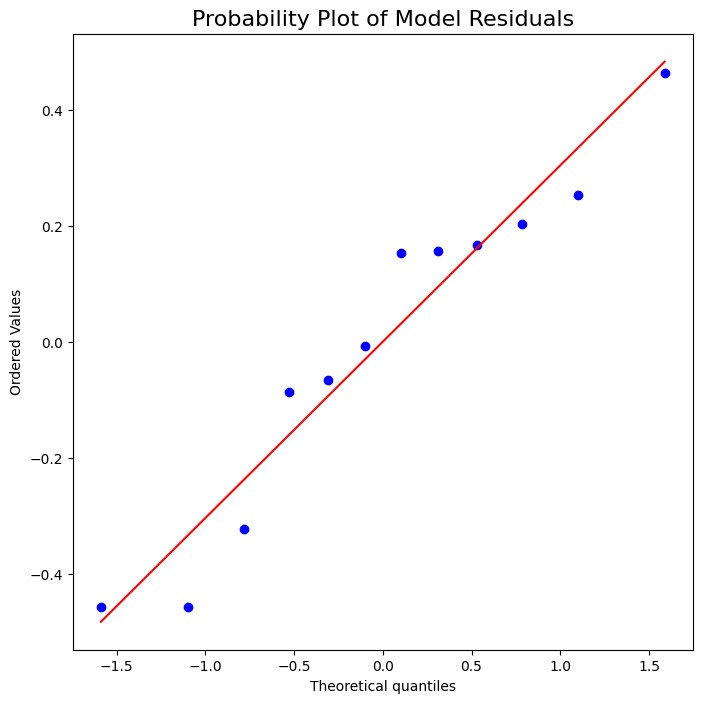

Shapiro-Wilk Test Statistic: 0.9284071225902285
p-value: 0.36353430745848825


In [23]:
## Question 8 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan


# Fit ANOVA model with main effects and interactions (3-factor)
model = ols(
    "Satisfaction ~ GPS_Accuracy * Battery_Life * Display",
    data=Band_Experiment_ds
).fit()

# Extract residuals
res = model.resid

# Generate QQ-plot for normality check
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)
stats.probplot(res, plot=plt)
ax.set_title("Probability Plot of Model Residuals", fontsize=16)
plt.show()

# Shapiro-Wilk test for normality
shapiro_test = stats.shapiro(res)
print(f'Shapiro-Wilk Test Statistic: {shapiro_test.statistic}')
print(f'p-value: {shapiro_test.pvalue}')


The Q-Q plot shows that most of the residuals lie along the diagonal line, with only minor deviations in the lower tail, suggesting that the normality assumption is reasonably satisfied.

The Shapiro-Wilk test yields a p-value greater than 0.05, providing no evidence to reject the null hypothesis and further supporting the assumption that the residuals are approximately normally distributed.


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


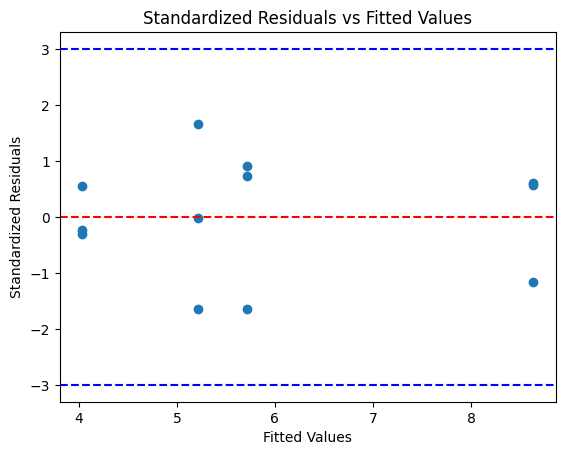

Breusch-Pagan F-statistic: 1.5383564718475269
Breusch-Pagan p-value: 0.27793737988382233


In [24]:
## Question 9 Code ##

# Scatterplot of standardized residuals vs fitted values
standard_res = model.get_influence().resid_studentized_internal
fitted_vals = model.fittedvalues

plt.scatter(fitted_vals, standard_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=3, color='b', linestyle='--')
plt.axhline(y=-3, color='b', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Standardized Residuals')
plt.title('Standardized Residuals vs Fitted Values')
plt.show()

# Breusch-Pagan test for homoscedasticity
bp_test = het_breuschpagan(res, model.model.exog)
f_statistic = bp_test[2]
f_p_value = bp_test[3]

print(f"Breusch-Pagan F-statistic: {f_statistic}")
print(f"Breusch-Pagan p-value: {f_p_value}")

 For constant variance:
    - The scatterplot of the fitted values vs the standardized residuals shows:
        - No points are greater than +3 or less than -3
        - The residuals are randomly scattered around zero implying that zero is a good estimate of the mean of the residuals.
        - The heights of the residuals appear to be roughly constant across the range of fitted values, indicating constant variance.
    - The B-P test statistic is associated with a p-value greater than 0.05, further indicating that the data are supportive of the assumption of constant variance.

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [25]:
## Question 10 Code ##

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

## Print ANOVA table ##
anova_table = sm.stats.anova_lm(model, typ=3)

## Add Significance Column ##
anova_table['Significance'] = np.where(anova_table['PR(>F)'] < 0.05, 'Significant', 'Not Significant')

print(anova_table)


                                       sum_sq   df            F        PR(>F)  \
Intercept                          223.603333  1.0  1924.159197  8.049463e-11   
GPS_Accuracy                        19.476267  1.0   167.597849  1.200088e-06   
Battery_Life                         7.592425  1.0    65.334596  4.053896e-05   
Display                             26.169688  1.0   225.196309  3.840427e-07   
GPS_Accuracy:Battery_Life            1.820024  1.0    15.661736  4.191749e-03   
GPS_Accuracy:Display                19.811297  1.0   170.480863  1.124062e-06   
Battery_Life:Display                 5.163206  1.0    44.430601  1.582253e-04   
GPS_Accuracy:Battery_Life:Display         NaN  1.0          NaN           NaN   
Residual                             0.929667  8.0          NaN           NaN   

                                      Significance  
Intercept                              Significant  
GPS_Accuracy                           Significant  
Battery_Life                  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1923: RuntimeWarning: invalid value encountered in divide


All main factors (GPS_Accuracy, Battery_Life, Display) significantly affect the response (p < 0.05).
Two-way interactions are also significant (p < 0.05),the effect of one factor depends on another.
Three-way interaction is not significant

11. Calculate and interpret the values for the main effects.


Which effects seem more important? Why?




In [29]:
## Question 11 Code ##
import pandas as pd
import numpy as np

# 4 runs, 3 replicates each → 12 rows
effects = ["(1)", "A", "B", "C"]
fitness_band = Band_Experiment_ds.assign(Effect=np.repeat(effects, 3))

# Compute mean satisfaction per run
df_means = fitness_band.groupby("Effect", as_index=False)["Satisfaction"].mean()

# Pivot wider
df_wide = df_means.pivot_table(index=None, columns="Effect", values="Satisfaction")

# Extract columns
base = df_wide["(1)"]
A    = df_wide["A"]
B    = df_wide["B"]
C    = df_wide["C"]

# Compute main effects (fractional factorial)
effects_result = pd.DataFrame({
    "A": 0.5 * (-base + A),
    "B": 0.5 * (-base + B),
    "C": 0.5 * (-base + C)
})

print("Factorial Effects Table (Fitness Band, Fractional Factorial):\n")
print(effects_result)

Factorial Effects Table (Fitness Band, Fractional Factorial):

                 A     B         C
Satisfaction -0.25 -0.84  1.458333


To maximize user satisfaction, the company should prioritize a Large Display (C+).GPS Accuracy (A-) and Battery Life (B-) are less critical, and increasing them might even slightly reduce satisfaction according to this dataset.

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [34]:
## Question 12 Code ##

#!pip install pingouin
import pingouin as pg

# Calculate Partial Eta Squared Effect Sizes
effect_sizes = pg.anova(
    dv="Satisfaction",
    between=["GPS_Accuracy", "Battery_Life", "Display"],
    data=Band_Experiment_ds,
    detailed=True
)

# Display main effects and interactions
print(effect_sizes[['Source', 'np2']])

                                  Source       np2
0                           GPS_Accuracy  0.931221
1                           Battery_Life  0.708721
2                                Display  0.954454
3            GPS_Accuracy * Battery_Life  0.954454
4                 GPS_Accuracy * Display  0.708721
5                 Battery_Life * Display  0.931221
6  GPS_Accuracy * Battery_Life * Display  0.997780
7                               Residual       NaN


13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?